In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [2]:
df=pd.read_csv("DATA/potato.csv")

df

,Date,price
0,2000-01-01 00:00:00,70.7
1,2000-02-01 00:00:00,58.6
2,2000-03-01 00:00:00,67.0
3,2000-04-01 00:00:00,68.7
4,2000-05-01 00:00:00,77.8
...,...,...
277,2023-02-01 00:00:00,146.0
278,2023-03-01 00:00:00,135.2
279,2023-04-01 00:00:00,157.0
280,2023-05-01 00:00:00,190.0


<Axes: >

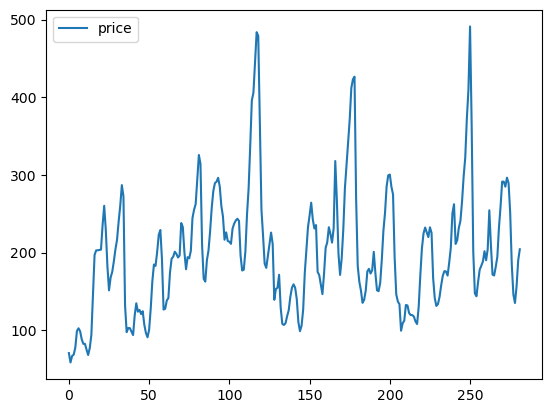

In [3]:
df.plot()

<Axes: >

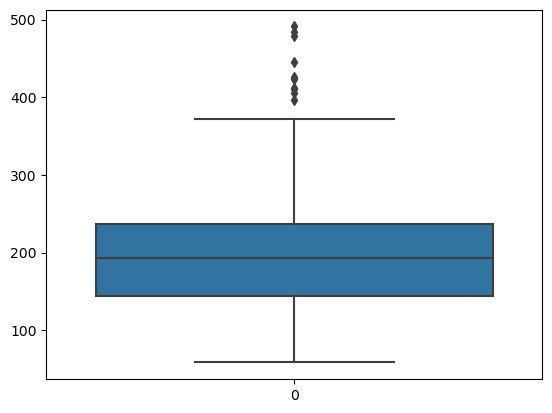

In [4]:
sn.boxplot(df['price'])

In [13]:
t=kpss(df['price'],'ct')
t

(0.13325745998218122,
 0.07359729632929403,
 9,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

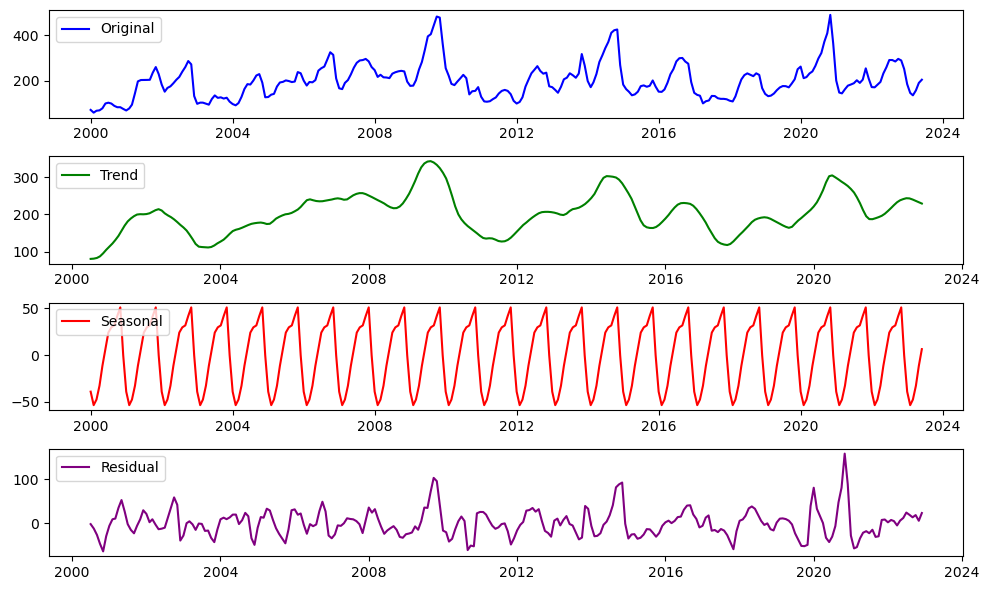

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is your DataFrame with a 'date' column and a 'value' column representing the time series
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['price'], model='additive')

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(df['price'], label='Original', color='blue')
plt.legend(loc='upper left')

# Plot the trend component
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='green')
plt.legend(loc='upper left')

# Plot the seasonal component
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='red')
plt.legend(loc='upper left')

# Plot the residual component
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='purple')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


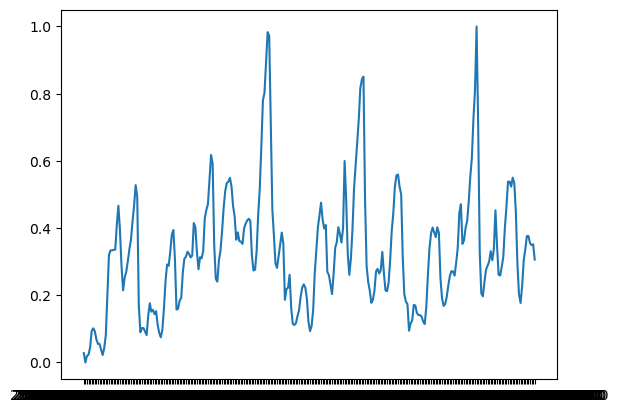

In [363]:
df=pd.read_csv("DATA/Backup/potato.csv")
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['price'])

In [364]:
# Convert 'date' column to datetime if it's not already
# Shift the 'price' column to create new columns
df['target-1'] = df['price'].shift(1)
df['target-2'] = df['price'].shift(2)
df['target-3'] = df['price'].shift(3)
#df['target-4'] = df['price'].shift(4)
#df['target-5'] = df['price'].shift(5)
#df['target-6'] = df['price'].shift(6)
#df['target-7'] = df['price'].shift(7)
#df['target-8'] = df['price'].shift(8)
#df['target-9'] = df['price'].shift(9)
#df['target-10'] = df['price'].shift(10)

In [365]:
d=df[3:]
d

,Date,price,target-1,target-2,target-3
3,2000-04-01 00:00:00,0.023353,0.019422,0.000000,0.027977
4,2000-05-01 00:00:00,0.044393,0.023353,0.019422,0.000000
5,2000-06-01 00:00:00,0.093642,0.044393,0.023353,0.019422
6,2000-07-01 00:00:00,0.101734,0.093642,0.044393,0.023353
7,2000-08-01 00:00:00,0.092948,0.101734,0.093642,0.044393
...,...,...,...,...,...
283,2023-08-01 00:00:00,0.376416,0.376185,0.336879,0.303815
284,2023-09-01 00:00:00,0.355145,0.376416,0.376185,0.336879
285,2023-10-01 00:00:00,0.349364,0.355145,0.376416,0.376185
286,2023-11-01 00:00:00,0.351676,0.349364,0.355145,0.376416


In [366]:
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 1:-1]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, -1]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)

dates.shape, X.shape, y.shape

((285,), (285, 3, 1), (285,))

In [367]:
#y

In [368]:
#dates
#X
#y

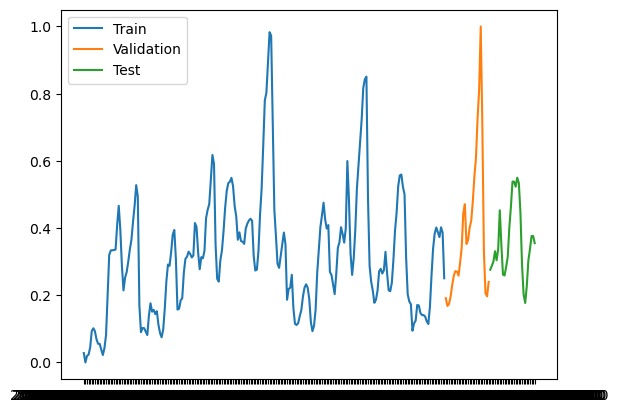

In [369]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [370]:
X_train.shape,

((228, 3, 1),)

In [416]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

#early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min')

model = Sequential([layers.Input((3, 1)),
                    #layers.GRU(64),
                    #layers.LSTM(64),
                    #layers.LSTM(32, return_sequences=True),
                    #layers.LSTM(32),
                    #layers.Bidirectional(layers.LSTM(64)),
                    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
                    layers.Flatten(),
                    layers.Dense(64, activation='relu'),
                    #layers.Dense(32, activation='relu'),
                    layers.Dense(1)
                   ])

model.compile(loss='mse', 
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=250)

Epoch 1/250
8/8 [==============================] - 0s 8ms/step - loss: 0.0677 - mean_absolute_error: 0.2105 - val_loss: 0.0456 - val_mean_absolute_error: 0.1275
Epoch 2/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0171 - mean_absolute_error: 0.0921 - val_loss: 0.0296 - val_mean_absolute_error: 0.1342
Epoch 3/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0169 - mean_absolute_error: 0.1089 - val_loss: 0.0270 - val_mean_absolute_error: 0.1272
Epoch 4/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0127 - mean_absolute_error: 0.0859 - val_loss: 0.0233 - val_mean_absolute_error: 0.0829
Epoch 5/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0108 - mean_absolute_error: 0.0731 - val_loss: 0.0210 - val_mean_absolute_error: 0.0820
Epoch 6/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0096 - mean_absolute_error: 0.0691 - val_loss: 0.0194 - val_mean_absolute_error: 0.0774
Epoch 7/250
8/8 [=================

8/8 [==============================] - 0s 2ms/step - loss: 0.0035 - mean_absolute_error: 0.0413 - val_loss: 0.0097 - val_mean_absolute_error: 0.0622
Epoch 52/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0037 - mean_absolute_error: 0.0423 - val_loss: 0.0085 - val_mean_absolute_error: 0.0571
Epoch 53/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0034 - mean_absolute_error: 0.0390 - val_loss: 0.0087 - val_mean_absolute_error: 0.0561
Epoch 54/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0034 - mean_absolute_error: 0.0393 - val_loss: 0.0088 - val_mean_absolute_error: 0.0557
Epoch 55/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0036 - mean_absolute_error: 0.0403 - val_loss: 0.0085 - val_mean_absolute_error: 0.0579
Epoch 56/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0035 - mean_absolute_error: 0.0396 - val_loss: 0.0086 - val_mean_absolute_error: 0.0560
Epoch 57/250
8/8 [=======================

8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0388 - val_loss: 0.0076 - val_mean_absolute_error: 0.0589
Epoch 102/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0402 - val_loss: 0.0080 - val_mean_absolute_error: 0.0559
Epoch 103/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0391 - val_loss: 0.0078 - val_mean_absolute_error: 0.0557
Epoch 104/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0034 - mean_absolute_error: 0.0409 - val_loss: 0.0085 - val_mean_absolute_error: 0.0673
Epoch 105/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0039 - mean_absolute_error: 0.0460 - val_loss: 0.0082 - val_mean_absolute_error: 0.0557
Epoch 106/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0402 - val_loss: 0.0077 - val_mean_absolute_error: 0.0556
Epoch 107/250
8/8 [=================

8/8 [==============================] - 0s 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0388 - val_loss: 0.0076 - val_mean_absolute_error: 0.0583
Epoch 152/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0407 - val_loss: 0.0076 - val_mean_absolute_error: 0.0543
Epoch 153/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0412 - val_loss: 0.0074 - val_mean_absolute_error: 0.0556
Epoch 154/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0402 - val_loss: 0.0073 - val_mean_absolute_error: 0.0547
Epoch 155/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0034 - mean_absolute_error: 0.0393 - val_loss: 0.0078 - val_mean_absolute_error: 0.0567
Epoch 156/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0395 - val_loss: 0.0077 - val_mean_absolute_error: 0.0540
Epoch 157/250
8/8 [=================

8/8 [==============================] - 0s 2ms/step - loss: 0.0031 - mean_absolute_error: 0.0385 - val_loss: 0.0075 - val_mean_absolute_error: 0.0565
Epoch 202/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0388 - val_loss: 0.0077 - val_mean_absolute_error: 0.0606
Epoch 203/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0043 - mean_absolute_error: 0.0504 - val_loss: 0.0110 - val_mean_absolute_error: 0.0733
Epoch 204/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0045 - mean_absolute_error: 0.0498 - val_loss: 0.0087 - val_mean_absolute_error: 0.0723
Epoch 205/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0043 - mean_absolute_error: 0.0457 - val_loss: 0.0085 - val_mean_absolute_error: 0.0520
Epoch 206/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0413 - val_loss: 0.0079 - val_mean_absolute_error: 0.0539
Epoch 207/250
8/8 [=================

In [417]:
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')


Training Loss: [0.0030461223796010017, 0.03706270456314087]
Testing Loss: [0.002200337126851082, 0.03385021910071373]


8/8 [==============================] - 0s 511us/step


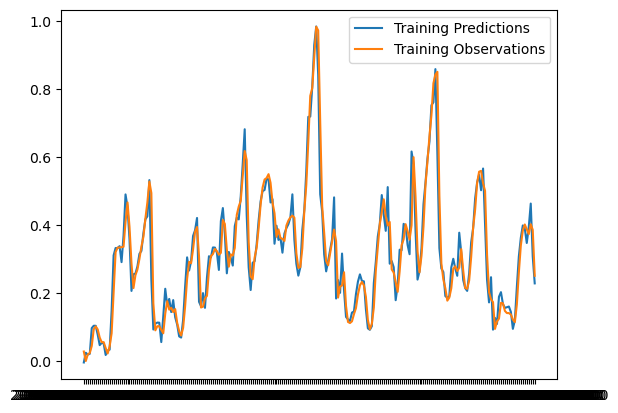

In [418]:
train_predictions = model.predict(X_train)

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)

#plt.plot(train_predictions)
#plt.plot(y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 [==============================] - 0s 11ms/step


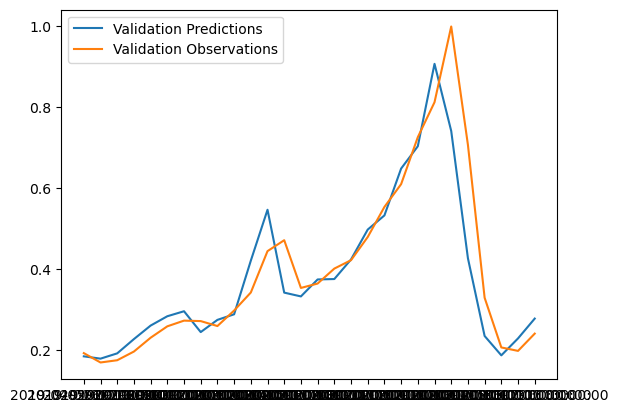

In [419]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 [==============================] - 0s 11ms/step


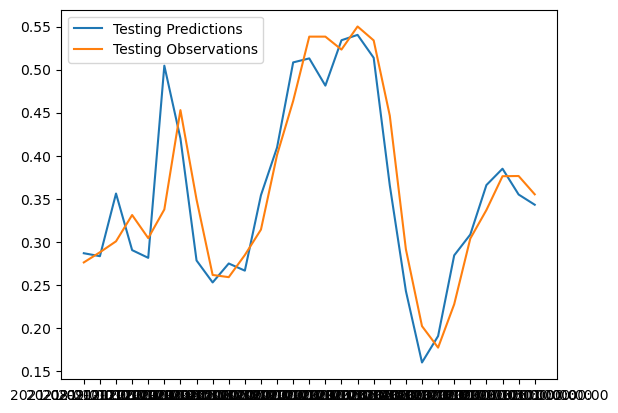

In [420]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [421]:
#test_predictions

In [422]:
# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(train_predictions.reshape(-1,1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))
y_val_pred_actual = scaler.inverse_transform(val_predictions.reshape(-1,1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1,1))


In [423]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
val_mae = mean_absolute_error(y_val_actual, y_val_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
val_mse = mean_squared_error(y_val_actual, y_val_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Val MAE: {val_mae}')
print(f'Val MSE: {val_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')


train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(train_r2)
print(val_r)
print(val_r2)
print(test_r)
print(test_r2)

Training MAE: 16.029621124267578
Training MSE: 569.7963256835938
Val MAE: 22.895456314086914
Val MSE: 1392.8931884765625
Testing MAE: 14.640216827392578
Testing MSE: 411.5867919921875
23.870407
0.9069555309237731
37.321484
0.8304717003760734
20.287601
0.7993115813717199


In [140]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train, train_predictions)
train_mse = mean_squared_error(y_train, train_predictions)
val_mae = mean_absolute_error(y_val, val_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
val_mse = mean_squared_error(y_val, val_predictions)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')
print(f'Testing MAE: {val_mae}')
print(f'Testing MSE: {val_mse}')

train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(val_r)
print(test_r)
print(train_r2)
print(val_r2)
print(test_r2)

Training MAE: 0.03931098058819771
Training MSE: 0.0032352623529732227
Testing MAE: 0.03548557311296463
Testing MSE: 0.0023003045935183764
Testing MAE: 0.056559350341558456
Testing MSE: 0.007438889238983393
0.056879368
0.086248994
0.047961492
0.9026494483238845
0.8178772464656185
0.821485557583796


In [428]:
model.save('potato_cnn')

INFO:tensorflow:Assets written to: potato_cnn/assets


INFO:tensorflow:Assets written to: potato_cnn/assets


In [429]:
import tensorflow as tf
m1=tf.keras.models.load_model('potato_cnn')
m1.layers[0].input_shape

(None, 3, 1)

In [430]:
test_predictions = m1.predict(X_test).flatten()

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))

test_r2 = r2_score(y_test_actual, y_test_pred_actual)
print(test_r2)
#plt.plot(dates_test, test_predictions)
#plt.plot(dates_test, y_test)
#plt.legend(['Testing Predictions', 'Testing Observations'])

1/1 [==============================] - 0s 30ms/step
0.7993115813717199


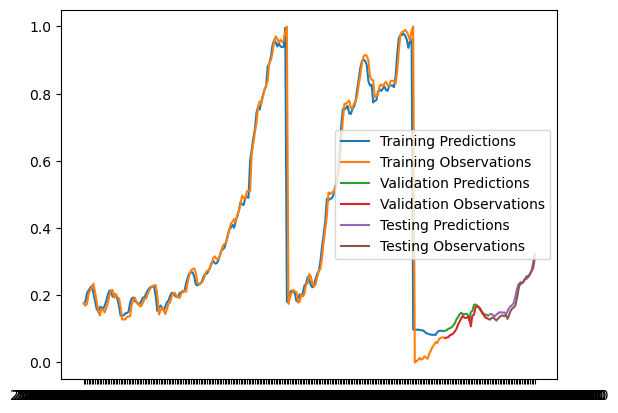

In [149]:
plt.plot(figsize=(100,100))
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'])



In [150]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 [==============================] - 0s 8ms/step


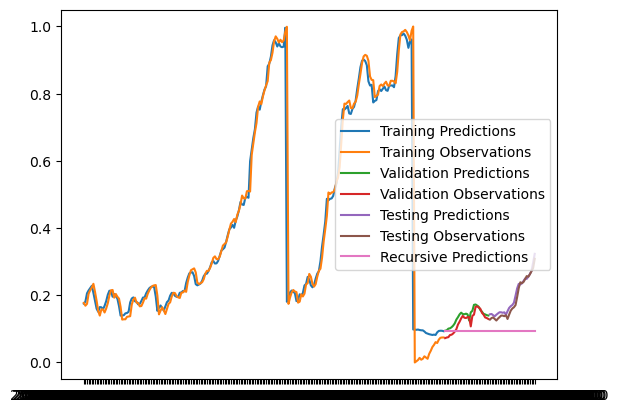

In [151]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations',
            'Recursive Predictions'])

In [72]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
# Sample DataFrame
#data = {'date': pd.date_range(start='2024-01-01', periods=100),
#        'price': np.random.rand(100)}
#df = pd.DataFrame(data)



In [63]:
# Normalize the price data
scaler = MinMaxScaler(feature_range=(0, 1))
d['price'] = scaler.fit_transform(d['Rice'].values.reshape(-1,1))

In [64]:
x=d.pop('Rice')
d

,date,price
0,2000-02-01,0.053404
1,2000-03-01,0.043292
2,2000-04-01,0.049974
3,2000-05-01,0.049490
4,2000-06-01,0.049135
...,...,...
235,2019-09-01,0.058386
236,2019-10-01,0.056683
237,2019-11-01,0.075554
238,2019-12-01,0.081035


In [65]:
# Function to create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Hyperparameters
sequence_length = 10  # Adjust according to your choice
batch_size = 64
epochs = 100

# Create sequences
X, y = create_sequences(d['price'].values, sequence_length)

# Split the data into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape input data for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [73]:
# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))

In [74]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [75]:
# Train the model
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)
# Define Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)


Epoch 1/100
3/3 [==============================] - 1s 6ms/step - loss: 0.0041
Epoch 2/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 3/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0027
Epoch 4/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0023
Epoch 5/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0023
Epoch 6/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0023
Epoch 7/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0021
Epoch 8/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0020
Epoch 9/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0021
Epoch 10/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0020
Epoch 11/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0019
Epoch 12/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0019
Epoch 13/100
3/3 [==============================] - 0s 6ms/st

In [76]:
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')


Training Loss: 0.0006569024408236146
Testing Loss: 0.04776032641530037


In [54]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(y_train_pred)
y_test_pred_actual = scaler.inverse_transform(y_test_pred)

# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
#
train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')
print(train_r)
print(test_r)
print(train_r2)
print(test_r2)

1/1 [==============================] - 0s 8ms/step
Training MAE: 15.197800636291504
Training MSE: 980.4922485351562
Testing MAE: 217.68800354003906
Testing MSE: 190393.921875
31.312813
436.34152
0.80162733858064
0.20735048207608497


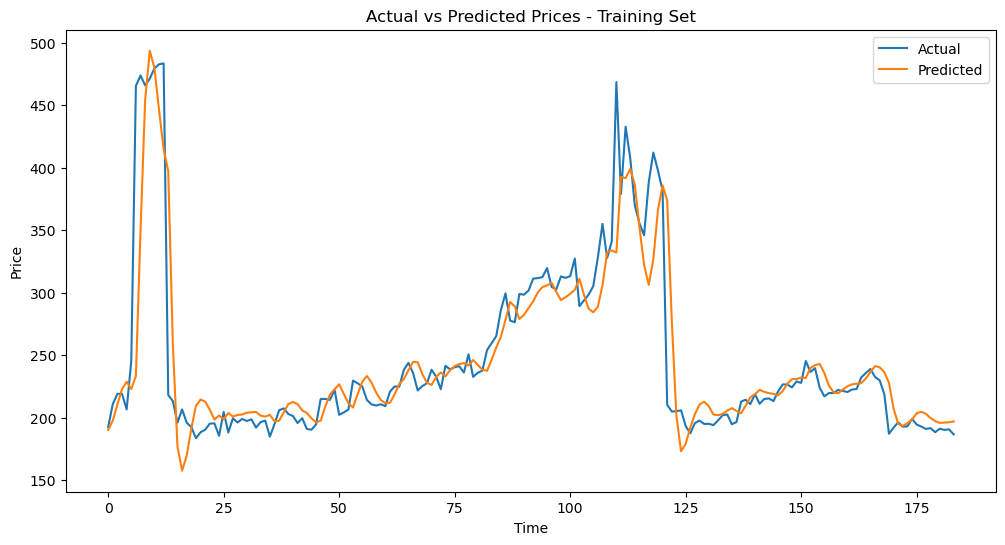

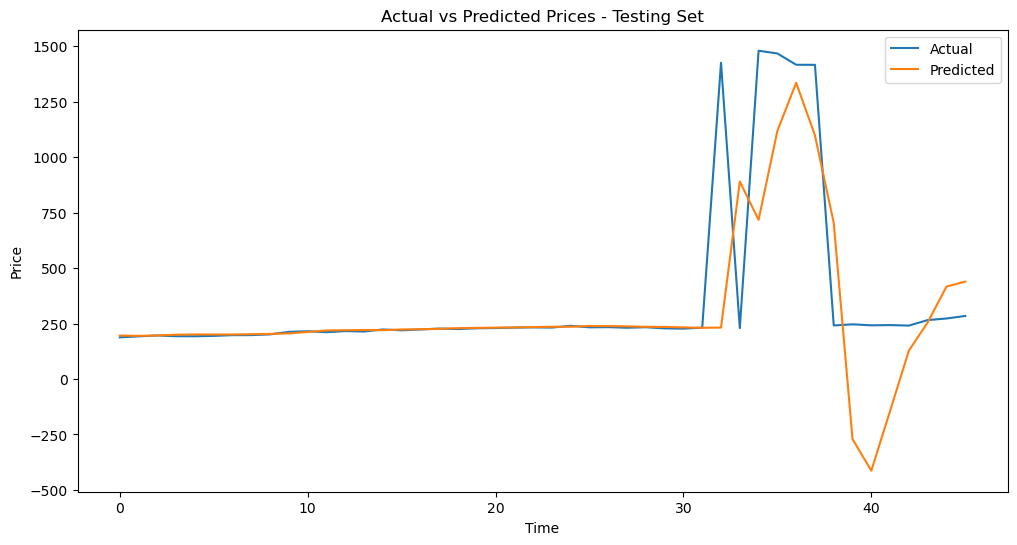

In [78]:
import matplotlib.pyplot as plt

# Plot actual vs predicted for training set
plt.figure(figsize=(12, 6))
plt.plot(y_train_actual, label='Actual')
plt.plot(y_train_pred_actual, label='Predicted')
plt.title('Actual vs Predicted Prices - Training Set')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot actual vs predicted for testing set
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_test_pred_actual, label='Predicted')
plt.title('Actual vs Predicted Prices - Testing Set')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [79]:
d

,date,price
0,2000-02-01,0.053404
1,2000-03-01,0.043292
2,2000-04-01,0.049974
3,2000-05-01,0.049490
4,2000-06-01,0.049135
...,...,...
235,2019-09-01,0.058386
236,2019-10-01,0.056683
237,2019-11-01,0.075554
238,2019-12-01,0.081035
